## 문제 2. 카메라 투영 행렬(Projection Matrix) 시각화

3D 공간의 점을 카메라를 통해 2D 이미지로 투영하는 전 과정을 단계별로 실습합니다.

#### 실험 순서
- **Step 1.** 카메라 파라미터 설정 (K, R, t → P)
- **Step 2.** 임의 3D 점 생성
- **Step 3.** 투영 연산 (Homogeneous 좌표계)
- **Step 4 & 5.** 이미지 시각화 및 투영 특성 분석

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows
# plt.rcParams["font.family"] = "AppleGothic"  # macOS
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# ── Step 1. 카메라 파라미터 설정 ──────────────────────────
IMG_W, IMG_H = 640, 480

def build_intrinsic(f: float, cx: float, cy: float) -> np.ndarray:
    """
    내부 파라미터 행렬 K (3×3)
      f  : 초점거리 (픽셀 단위)
      cx, cy : 주점 (이미지 중심)
    """
    return np.array([
        [f,  0, cx],
        [0,  f, cy],
        [0,  0,  1],
    ], dtype=np.float64)


def build_extrinsic(rx_deg: float = 0.0,
                    ry_deg: float = 0.0,
                    t: np.ndarray = None) -> tuple:
    """
    외부 파라미터 R (3×3), t (3,)
      rx_deg : X축 회전 (pitch — 위아래)
      ry_deg : Y축 회전 (yaw   — 좌우)
    """
    if t is None:
        t = np.array([0.0, -1.5, 5.0])

    rx, ry = np.deg2rad(rx_deg), np.deg2rad(ry_deg)

    Rx = np.array([
        [1,           0,            0],
        [0,  np.cos(rx), -np.sin(rx)],
        [0,  np.sin(rx),  np.cos(rx)],
    ])
    Ry = np.array([
        [ np.cos(ry), 0, np.sin(ry)],
        [          0, 1,          0],
        [-np.sin(ry), 0, np.cos(ry)],
    ])
    return Ry @ Rx, t


def build_projection_matrix(K, R, t) -> np.ndarray:
    """P = K [R | t]  (3×4)"""
    Rt = np.hstack([R, t.reshape(3, 1)])
    return K @ Rt


# ── 파라미터 값 설정 ──
f  = 400.0
cx, cy = IMG_W / 2, IMG_H / 2          # 주점 = 이미지 중심
K  = build_intrinsic(f, cx, cy)

R, t = build_extrinsic(rx_deg=10.0, ry_deg=5.0,
                        t=np.array([0.0, -1.5, 5.0]))
P = build_projection_matrix(K, R, t)

print("[ K ] 내부 파라미터 행렬")
print(K)
print("\n[ R ] 회전 행렬")
print(np.round(R, 4))
print("\n[ t ] 이동 벡터")
print(t)
print("\n[ P ] Projection Matrix (3×4)")
print(np.round(P, 3))

[ K ] 내부 파라미터 행렬
[[400.   0. 320.]
 [  0. 400. 240.]
 [  0.   0.   1.]]

[ R ] 회전 행렬
[[ 0.9962  0.0151  0.0858]
 [ 0.      0.9848 -0.1736]
 [-0.0872  0.173   0.9811]]

[ t ] 이동 벡터
[ 0.  -1.5  5. ]

[ P ] Projection Matrix (3×4)
[[ 3.70588e+02  6.14100e+01  3.48272e+02  1.60000e+03]
 [-2.09170e+01  4.35440e+02  1.65995e+02  6.00000e+02]
 [-8.70000e-02  1.73000e-01  9.81000e-01  5.00000e+00]]


In [3]:
# ── Step 2. 임의 3D 점 생성 ───────────────────────────────

def generate_3d_points(n=150,
                        x_range=(-6, 6),
                        y_range=(-3, 3),
                        z_range=(1, 20),
                        seed=42) -> np.ndarray:
    """
    반환: (n, 3) 배열 — 각 행이 [X, Y, Z]
    """
    rng = np.random.default_rng(seed)
    X = rng.uniform(*x_range, n)
    Y = rng.uniform(*y_range, n)
    Z = rng.uniform(*z_range, n)
    return np.column_stack([X, Y, Z])


pts_3d = generate_3d_points(n=150, z_range=(1, 20), seed=42)

print(f"3D 점 생성: {len(pts_3d)}개")
print(f"  X range : [{pts_3d[:,0].min():.2f}, {pts_3d[:,0].max():.2f}]")
print(f"  Y range : [{pts_3d[:,1].min():.2f}, {pts_3d[:,1].max():.2f}]")
print(f"  Z range : [{pts_3d[:,2].min():.2f}, {pts_3d[:,2].max():.2f}]")

3D 점 생성: 150개
  X range : [-5.91, 5.71]
  Y range : [-2.92, 2.95]
  Z range : [1.10, 19.98]


In [4]:
# ── Step 3. 투영 연산 ─────────────────────────────────────

def project_points(P, points_3d):
    """
    반환
    ----
    pts_2d : (n, 2)  이미지 좌표 (u, v)
    valid  : (n,)    bool — 카메라 앞쪽(w > 0)
    """
    n    = len(points_3d)
    ones = np.ones((n, 1))
    X_h  = np.hstack([points_3d, ones])   # (n, 4) homogeneous

    x_h  = P @ X_h.T                      # (3, n)
    w    = x_h[2]
    valid = w > 0

    u = np.where(valid, x_h[0] / w, np.nan)
    v = np.where(valid, x_h[1] / w, np.nan)

    return np.column_stack([u, v]), valid


pts_2d, valid = project_points(P, pts_3d)

in_image = (
    valid &
    (pts_2d[:, 0] >= 0) & (pts_2d[:, 0] < IMG_W) &
    (pts_2d[:, 1] >= 0) & (pts_2d[:, 1] < IMG_H)
)

print(f"유효한 점 (w > 0) : {valid.sum()}개")
print(f"화면 내 점        : {in_image.sum()}개")
print(f"클리핑된 점       : {len(pts_3d) - in_image.sum()}개")

유효한 점 (w > 0) : 150개
화면 내 점        : 145개
클리핑된 점       : 5개


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_34156\444136520.py:140: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig("projection_result.png", dpi=150,
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


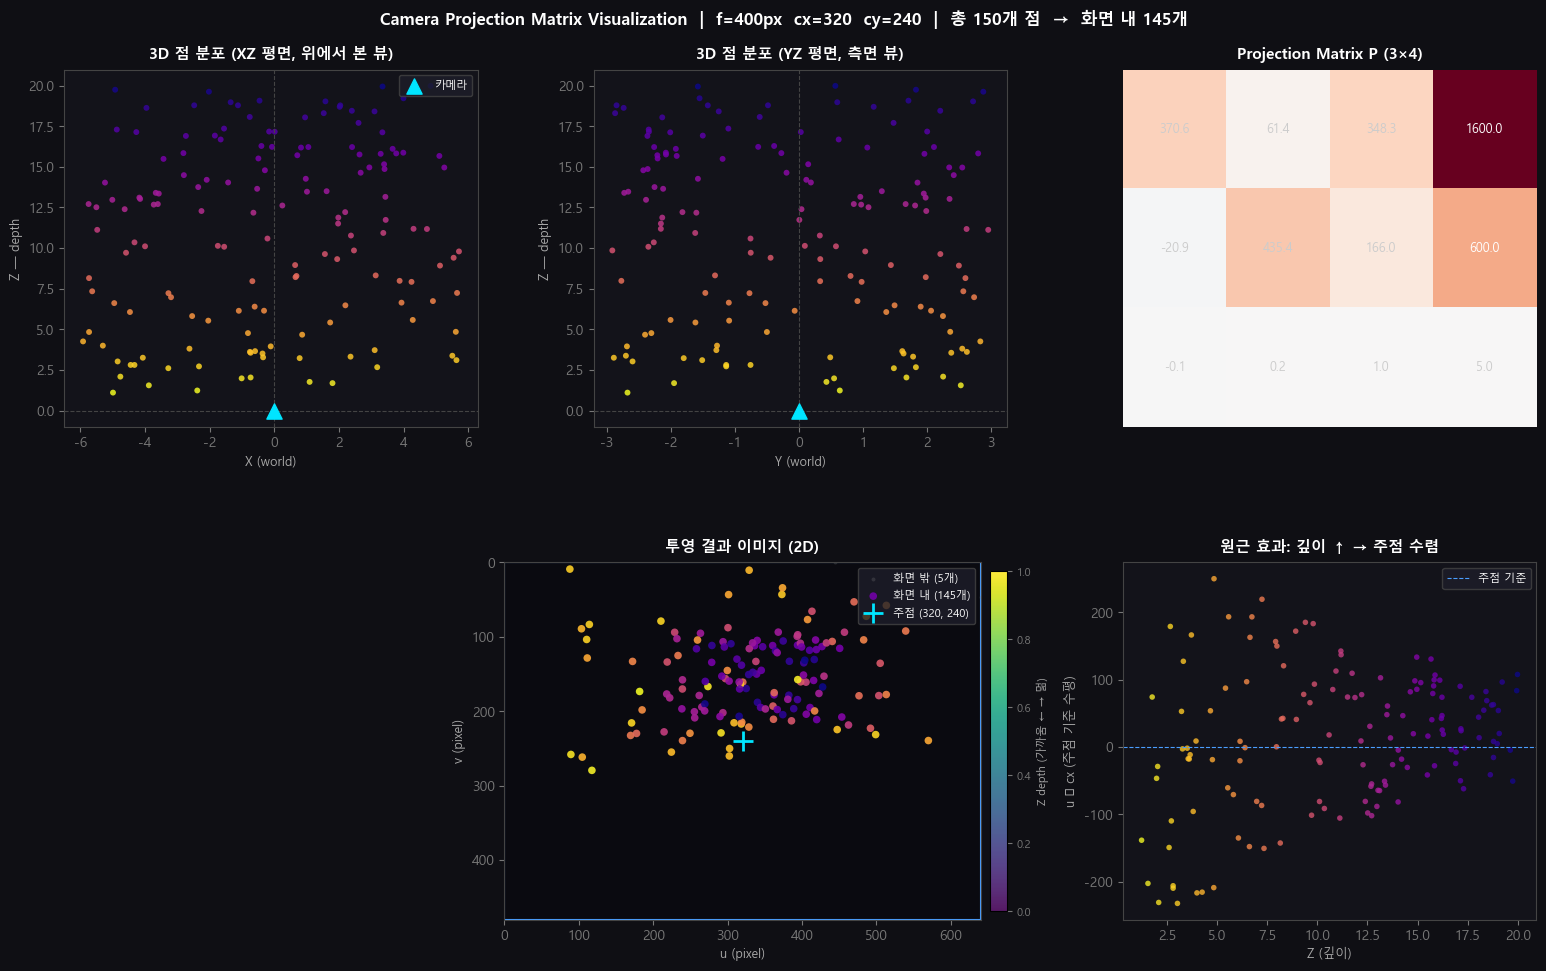

[완료] projection_result.png 저장됨


In [5]:
# ── Step 4 & 5. 시각화 ────────────────────────────────────

cx_k, cy_k = K[0, 2], K[1, 2]
depth       = pts_3d[:, 2]

norm_depth = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)
colors     = cm.plasma(1.0 - norm_depth)

spine_color = "#444"
title_kw    = dict(color="white", fontsize=11, fontweight="bold", pad=8)

fig = plt.figure(figsize=(16, 10), facecolor="#0f0f14")
gs  = GridSpec(2, 3, figure=fig,
               left=0.05, right=0.97,
               top=0.91,  bottom=0.06,
               hspace=0.38, wspace=0.28)

# ── 패널 A: XZ 평면 ──────────────────────────────────────
ax_xz = fig.add_subplot(gs[0, 0])
ax_xz.set_facecolor("#13131a")
ax_xz.scatter(pts_3d[:, 0], pts_3d[:, 2],
              c=colors, s=18, alpha=0.85, linewidths=0)
ax_xz.set_xlabel("X (world)", color="#aaa", fontsize=9)
ax_xz.set_ylabel("Z — depth", color="#aaa", fontsize=9)
ax_xz.set_title("3D 점 분포 (XZ 평면, 위에서 본 뷰)", **title_kw)
ax_xz.axhline(0, color=spine_color, lw=0.8, ls="--")
ax_xz.axvline(0, color=spine_color, lw=0.8, ls="--")
ax_xz.scatter(0, 0, marker="^", s=120, color="#00e5ff", zorder=5, label="카메라")
ax_xz.legend(fontsize=8, labelcolor="white",
              facecolor="#1e1e2a", edgecolor=spine_color)
ax_xz.tick_params(colors="#777")
for sp in ax_xz.spines.values():
    sp.set_edgecolor(spine_color)

# ── 패널 B: YZ 평면 ──────────────────────────────────────
ax_yz = fig.add_subplot(gs[0, 1])
ax_yz.set_facecolor("#13131a")
ax_yz.scatter(pts_3d[:, 1], pts_3d[:, 2],
              c=colors, s=18, alpha=0.85, linewidths=0)
ax_yz.set_xlabel("Y (world)", color="#aaa", fontsize=9)
ax_yz.set_ylabel("Z — depth", color="#aaa", fontsize=9)
ax_yz.set_title("3D 점 분포 (YZ 평면, 측면 뷰)", **title_kw)
ax_yz.axhline(0, color=spine_color, lw=0.8, ls="--")
ax_yz.axvline(0, color=spine_color, lw=0.8, ls="--")
ax_yz.scatter(0, 0, marker="^", s=120, color="#00e5ff", zorder=5)
ax_yz.tick_params(colors="#777")
for sp in ax_yz.spines.values():
    sp.set_edgecolor(spine_color)

# ── 패널 C: Projection Matrix 히트맵 ─────────────────────
ax_mat = fig.add_subplot(gs[0, 2])
ax_mat.set_facecolor("#13131a")
ax_mat.axis("off")
ax_mat.set_title("Projection Matrix P (3×4)", **title_kw)
ax_mat.imshow(P, cmap="RdBu_r", aspect="auto",
               vmin=-P.max(), vmax=P.max(),
               extent=[-0.5, 3.5, 2.5, -0.5])
for i in range(3):
    for j in range(4):
        val = P[i, j]
        ax_mat.text(j, i, f"{val:.1f}", ha="center", va="center",
                    fontsize=9,
                    color="white" if abs(val) > P.max() * 0.3 else "#ccc")
ax_mat.set_xticks(range(4))
ax_mat.set_xticklabels(["col 0","col 1","col 2","col 3"],
                        color="#777", fontsize=8)
ax_mat.set_yticks(range(3))
ax_mat.set_yticklabels(["row 0","row 1","row 2"],
                        color="#777", fontsize=8)

# ── 패널 D: 2D 투영 결과 이미지 ──────────────────────────
ax_img = fig.add_subplot(gs[1, :2])
ax_img.set_facecolor("#0a0a10")
ax_img.set_xlim(0, IMG_W)
ax_img.set_ylim(IMG_H, 0)
ax_img.set_aspect("equal")

border = mpatches.FancyBboxPatch(
    (0, 0), IMG_W, IMG_H,
    boxstyle="square,pad=0", linewidth=1.5,
    edgecolor="#4a9eff", facecolor="none"
)
ax_img.add_patch(border)

out_mask = valid & ~in_image
if out_mask.any():
    ax_img.scatter(pts_2d[out_mask, 0], pts_2d[out_mask, 1],
                   c="gray", s=8, alpha=0.25, linewidths=0,
                   label=f"화면 밖 ({out_mask.sum()}개)")

sc2 = ax_img.scatter(pts_2d[in_image, 0], pts_2d[in_image, 1],
                      c=colors[in_image], s=30, alpha=0.9,
                      linewidths=0,
                      label=f"화면 내 ({in_image.sum()}개)")

ax_img.plot(cx_k, cy_k, "+", color="#00e5ff", ms=14, mew=2,
            label=f"주점 ({cx_k:.0f}, {cy_k:.0f})")

cbar = fig.colorbar(sc2, ax=ax_img, fraction=0.018, pad=0.01)
cbar.set_label("Z depth (가까움 ← → 멂)", color="#aaa", fontsize=8)
cbar.ax.yaxis.set_tick_params(color="#777")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#777", fontsize=8)

ax_img.set_xlabel("u (pixel)", color="#aaa", fontsize=9)
ax_img.set_ylabel("v (pixel)", color="#aaa", fontsize=9)
ax_img.set_title("투영 결과 이미지 (2D)", **title_kw)
ax_img.legend(loc="upper right", fontsize=8, labelcolor="white",
               facecolor="#1e1e2a", edgecolor=spine_color)
ax_img.tick_params(colors="#777")
for sp in ax_img.spines.values():
    sp.set_edgecolor(spine_color)

# ── 패널 E: 원근 효과 분석 ────────────────────────────────
ax_persp = fig.add_subplot(gs[1, 2])
ax_persp.set_facecolor("#13131a")

z_in     = depth[in_image]
u_center = pts_2d[in_image, 0] - cx_k

ax_persp.scatter(z_in, u_center,
                 c=colors[in_image], s=16, alpha=0.8, linewidths=0)
ax_persp.axhline(0, color="#4a9eff", lw=0.8, ls="--", label="주점 기준")
ax_persp.set_xlabel("Z (깊이)", color="#aaa", fontsize=9)
ax_persp.set_ylabel("u − cx (주점 기준 수평)", color="#aaa", fontsize=9)
ax_persp.set_title("원근 효과: 깊이 ↑ → 주점 수렴", **title_kw)
ax_persp.legend(fontsize=8, labelcolor="white",
                 facecolor="#1e1e2a", edgecolor=spine_color)
ax_persp.tick_params(colors="#777")
for sp in ax_persp.spines.values():
    sp.set_edgecolor(spine_color)

# ── 전체 제목 ─────────────────────────────────────────────
fig.suptitle(
    f"Camera Projection Matrix Visualization"
    f"  |  f={f:.0f}px  cx={cx_k:.0f}  cy={cy_k:.0f}"
    f"  |  총 {len(pts_3d)}개 점  →  화면 내 {in_image.sum()}개",
    color="white", fontsize=12, fontweight="bold", y=0.97
)

plt.savefig("projection_result.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("[완료] projection_result.png 저장됨")

## 결과 분석

projection_result.png의 결과를 확인하면 다음과 같습니다.

### 1. XZ평면에서 확인한 3D 점 분포

X축은 좌우이고, Z축은 깊이를 나타냅니다. 해당 그래프는 카메라를 위에서 아래로 내려다보는 시점을 나타냈으며, ▲ 표시로 카메라의 위치를 표시하였습니다.

### 2. YZ평면에서 확인한 3D 점 분표

Y축은 상하이고, Z축은 깊이를 나타냅니다. 해당 그래프는 카메라를 옆에서 바라보는 시점을 나타냈으며, ▲ 표시로 카메라의 위치를 표시하였습니다.

### 3. Projection Matrix 시각화

Projection Matrix의 3*4 형식을 히트맵으로 표현하여 시각화하였습니다. Projection Matrix의 각 행은 위에서부터 각각 수평(u) 방향, 수직(v)방향, 깊이(w)를 나타냅니다.

$$\begin{bmatrix}
p_{00} & p_{01} & p_{02} & p_{03} \\
p_{10} & p_{11} & p_{12} & p_{13} \\
p_{20} & p_{21} & p_{22} & p_{23}
\end{bmatrix}
\begin{aligned}
&\leftarrow \text{row 0: } u(\text{수평}) \\
&\leftarrow \text{row 1: } v(\text{수직}) \\
&\leftarrow \text{row 2: 깊이 } w \text{ 계산}
\end{aligned}$$

값이 클수록 강한 색이 나타나고 0에 가까울수록 흰색에 가깝습니다.

- Row 2(깊이)
$$ \text{row 2} = \begin{bmatrix} -0.1 & 0.2 & 1.0 & 5.0 \end{bmatrix} $$

오른쪽부터 순서대로 X, Y, Z, 1 값을 나타냅니다. X와 Y의 축 값이 0에 가까운 값이므로 좌우로 약간, 위아래로 약간 기울어져 있음을 확인할 수 있습니다.


- Row 0(수평)

$$ \text{row 0} = \begin{bmatrix} 370.6 & 61.4 & 348.3 & 1600.0 \end{bmatrix} $$

오른쪽부터 순서대로 X, Y, Z, 1 값을 나타냅니다. row 2에서 확인한 것처럼 카메라가 X축으로 약간 기울어져서 수평선이 살짝 대각선으로 돌아간 상태입니다.


- Row 1(수직)

$$ \text{row 0} = \begin{bmatrix} -20.9 & 435.4 & 166.0 & 600.0 \end{bmatrix} $$

오른쪽부터 순서대로 X, Y, Z, 1 값을 나타냅니다. row 2에서 확인한 것처럼 카메라가 Y축으로 약간 기울어져서 수직선이 살짝 틀어진 상태입니다.


### 4. 2D 투영 결과 이미지

랜덤으로 생성한 150개의 3차원 점을 생성하여 2D에 투영한 결과를 그래프로 시각화한 결과입니다. 

150개의 점 중 145개는 화면 내의 점으로 색이 진한 점으로 표시되었고, 5개는 화면 외의 점으로 회색으로 눈에 띄지 않게 표시되었습니다. 화면 외의 점은 시야각 외의 좌표점으로, 3D에서는 존재하지만 카메라에 잡히지 않은 부분입니다. 화면 내의 점은 카메라와의 거리가 가까울수록 노란색에 가깝도록, 멀 수록 파란색에 가깝도록 표시하였습니다.

그래프에서는 노란 점, 즉 가까이 있는 좌표가 외곽에 퍼져 있고 파란색에 가까운 점, 즉 멀리 있는 좌표일수록 중앙에 모여 있습니다. 이는 화면에서의 원근감을 시각적으로 나타냅니다.


### 5. 원근 효과 분석

그래프의 X축(Z)은 좌표와 카메라와의 거리, Y축 (u-cx)은 좌표에서부터 만들어진 점이 카메라 화면 중앙으로부터 얼마나 떨어져 있는지에 대한 거리를 뜻합니다. 

그래프에서는 Z값이 클수록(점이 오른쪽에 있을수록) Y축의 0값에 가까워지는(Y값이 0에 가까워지는) 쌍곡선 형태를 이루고 있습니다. 이는 이미지 가장자리에 있을수록 카메라와 가까운 값, 이미지 중앙에 있을수록 카메라와 멀리 있다는 것을 확인할 수 있습니다.


## 결론
코드 결과를 이미지 위에 시각화함으로써 결과가 카메라 투영의 특성 중 이미지 경계 바깥쪽에 분포하는 부분이 더 가까이 있다는 원근감 특성과 일치함을 확인할 수 있습니다.